In [18]:
import cv2 as cv
import matplotlib.pyplot as plt
import pandas as pd
import csv
import numpy as np

In [19]:
cam_data = pd.read_csv("cam4_processed.csv")
joint_data = pd.read_csv("joint_log.csv")

# Keep only monotonic_ns and q5 from joint log and compute abs joint_ang relative to first q5
joint_data = joint_data[["monotonic_ns", "q5"]].copy()
joint_data["q5"] = pd.to_numeric(joint_data["q5"], errors="coerce")
joint_zero = joint_data["q5"].iloc[0]
joint_data["joint_ang"] = -(joint_data["q5"] - joint_zero) * 180.0 / np.pi

# Compute cam_ang from unit vectors x/y relative to first row angle, then use abs and cap over 90 by subtracting 90
cam_data = cam_data.copy()
cam_data["vector_x"] = pd.to_numeric(cam_data["vector_x"], errors="coerce")
cam_data["vector_y"] = pd.to_numeric(cam_data["vector_y"], errors="coerce")
first_cam_angle = np.arctan2(cam_data.loc[0, "vector_y"], cam_data.loc[0, "vector_x"])
cam_data["cam_ang"] = np.degrees(np.arctan2(cam_data["vector_y"], cam_data["vector_x"]) - first_cam_angle)
cam_data["cam_ang"] = ((cam_data["cam_ang"] + 180) % 360) - 180
# cam_data["cam_ang"] = np.abs(cam_data["cam_ang"])
# cam_data.loc[cam_data["cam_ang"] > 90, "cam_ang"] = 180 - cam_data.loc[cam_data["cam_ang"] > 90, "cam_ang"]

# Merge on monotonic_ns, keep both sides, sort and backfill missing values
merged = pd.merge(cam_data, joint_data, on="monotonic_ns", how="outer", suffixes=("_cam", "_joint"))
merged = merged.sort_values("monotonic_ns").reset_index(drop=True)
merged = merged.bfill()
merged = merged[["monotonic_ns", "captured_time_ns", "cam_ang", "joint_ang"]]

merged.head()

,monotonic_ns,captured_time_ns,cam_ang,joint_ang
0,24248385101603,2.424852e+13,0.000000,-0.0
1,24248401768269,2.424854e+13,-0.019620,-0.0
2,24248418434935,2.424855e+13,0.003952,-0.0
3,24248435101601,2.424857e+13,0.003952,-0.0
4,24248451768267,2.424859e+13,1.010769,-0.0


In [20]:
merged.to_csv("merged_output.csv", index=False)
print("Exported merged_output.csv")

Exported merged_output.csv


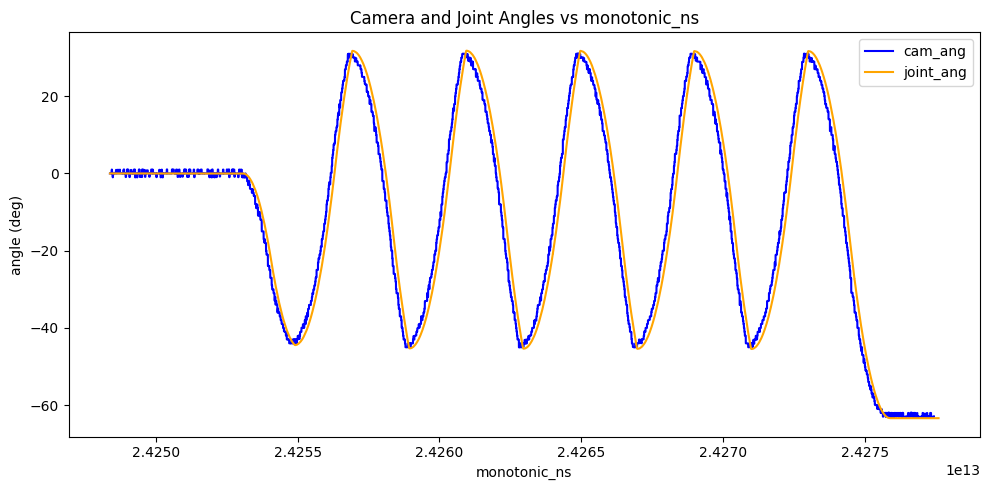

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(merged["monotonic_ns"], merged["cam_ang"], label="cam_ang", color="blue")
plt.plot(merged["monotonic_ns"], merged["joint_ang"], label="joint_ang", color="orange")
plt.xlabel("monotonic_ns")
plt.ylabel("angle (deg)")
plt.legend()
plt.title("Camera and Joint Angles vs monotonic_ns")
plt.tight_layout()
plt.show()

Estimated phase shift: -48 samples
Estimated phase shift: -95465496 ns (-0.095465 s)
Positive lag means cam_ang leads joint_ang. Negative lag means cam_ang lags joint_ang.


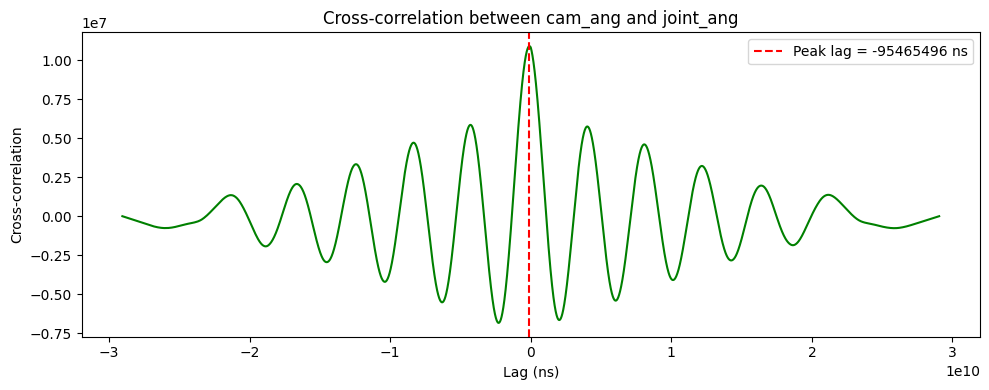

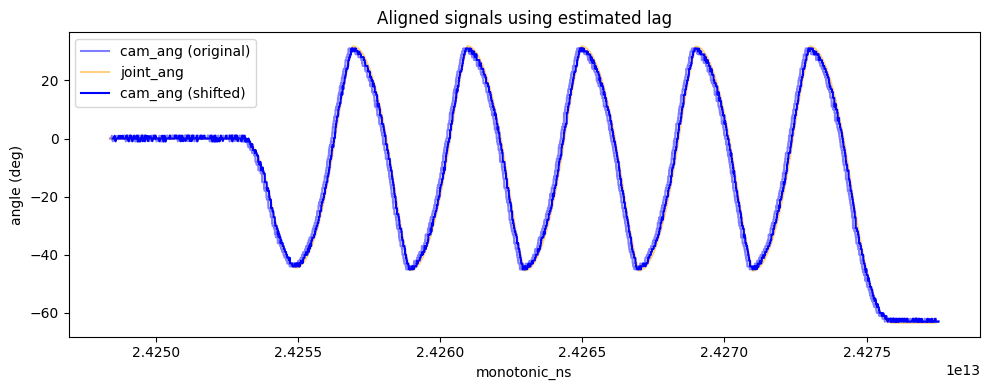

In [23]:
# Measure phase shift between cam_ang and joint_ang in monotonic_ns using cross-correlation.
clean = merged[['monotonic_ns', 'cam_ang', 'joint_ang']].dropna()
if len(clean) < 5:
    raise ValueError('Not enough matched data points to compute phase shift.')

times = clean['monotonic_ns'].to_numpy(dtype=np.float64)
cam = clean['cam_ang'].to_numpy(dtype=np.float64)
joint = clean['joint_ang'].to_numpy(dtype=np.float64)

# Resample to uniform time spacing for cross-correlation.
dt = np.median(np.diff(times))
uniform_times = np.arange(times[0], times[-1] + dt, dt)
cam_resampled = np.interp(uniform_times, times, cam)
joint_resampled = np.interp(uniform_times, times, joint)

cam_d = cam_resampled - np.mean(cam_resampled)
joint_d = joint_resampled - np.mean(joint_resampled)
correlation = np.correlate(cam_d, joint_d, mode='full')
lag_index = np.argmax(correlation) - (len(cam_d) - 1)
lag_ns = lag_index * dt
lag_sec = lag_ns * 1e-9

print(f'Estimated phase shift: {lag_index} samples')
print(f'Estimated phase shift: {lag_ns:.0f} ns ({lag_sec:.6f} s)')
print('Positive lag means cam_ang leads joint_ang. Negative lag means cam_ang lags joint_ang.')

# Visualize the cross-correlation and aligned signals.
plt.figure(figsize=(10, 4))
lag_times = np.arange(-len(cam_d) + 1, len(cam_d)) * dt
plt.plot(lag_times, correlation, color='green')
plt.axvline(lag_ns, color='red', linestyle='--', label=f'Peak lag = {lag_ns:.0f} ns')
plt.xlabel('Lag (ns)')
plt.ylabel('Cross-correlation')
plt.title('Cross-correlation between cam_ang and joint_ang')
plt.legend()
plt.tight_layout()
plt.show()

# Plot aligned signals after shifting cam_ang by the estimated lag.
shifted_times = uniform_times - lag_ns
plt.figure(figsize=(10, 4))
plt.plot(uniform_times, cam_resampled, label='cam_ang (original)', color='blue', alpha=0.5)
plt.plot(uniform_times, joint_resampled, label='joint_ang', color='orange', alpha=0.5)
plt.plot(shifted_times, cam_resampled, label='cam_ang (shifted)', color='blue')
plt.xlabel('monotonic_ns')
plt.ylabel('angle (deg)')
plt.title('Aligned signals using estimated lag')
plt.legend()
plt.tight_layout()
plt.show()